## update notes
1. delete the import of df_gtf
2. use new gff file zfin_genes_20250524

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import pingouin as pg
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
import math
import seaborn as sns
import pickle

In [4]:
traitlist = pd.read_csv('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Gwas/data/phenotype/20220822/traits.txt',sep=' ')
traitlist = list(traitlist.columns)[1:]

In [6]:
df_gff3 = pd.read_csv('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/ZebrafishGenomeAnnotation/zfin_genes_20250524.gff3',skiprows=38, delimiter='\t', header = None)
df_gff3 = df_gff3.dropna()

/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_96387/3468790284.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_gff3 = pd.read_csv('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/ZebrafishGenomeAnnotation/zfin_genes_20250524.gff3',skiprows=38, delimiter='\t', header = None)


In [612]:
df_all_ens = df_gff3.loc[df_gff3[2]=='gene'][8].apply(lambda x: [i for i in x.split(',') if i.startswith('ENSDARG')])
df_all_ens = df_all_ens.loc[df_all_ens.apply(lambda x: len(x))>0]
df_all_ens = df_all_ens.apply(lambda x: x[0])
df_all_ens = df_all_ens.loc[df_all_ens.apply(lambda x: len(x.split(';'))==1)]
df_all_ens.to_csv('bg_zgenes.csv')

### function to contruct an LD block

In [151]:
def ld_block_construction(traits, ld_dir, mlma_dir_updated, r2_high, r2_low):
    
    """
    this function is to build a dataset of information of LD blocks for each trait and it takes four arguments
    1). the traits argument is a list of trait names. e.g. ['Latency_to_1st_dark_zone_entry']
    2). the ld_dir argument is the directory where all the ld related data generated from wynton is stored. 
    e.g. '/Users/jialexu/Library/CloudStorage/Box-Box/UCSF/Research/Project2GWAS-BehvaioralGenetics/experiments/Gwas/data/LD_block/20220310/'
    3). the mlma_dir argument is the directory where all the mlma files are stored
    e.g. '/Users/jialexu/Library/CloudStorage/Box-Box/UCSF/Research/Project2GWAS-BehvaioralGenetics/experiments/Gwas/data/MLMA/20220103/'
    4). the r2 argument is the linkage disequilibrium threshold to define the LD block
    """
    def genes_in_block(snp, left, right):
        start = min(int(snp.split(':')[1]),left)
        end = max(int(snp.split(':')[1]),right)
        chr_num = int(snp.split(':')[0])
        df_gene = df_gff3.loc[df_gff3[0]== chr_num]
        df_gene = df_gene.loc[df_gene[2]=='gene']
        df_gene = df_gene.loc[(df_gene[4]>start)&(df_gene[3]<end)]
  
        return df_gene
    
    df_LD_block_single_trait_list = []
    for trait in traits:
        ### read all the needed data files for the current trait
        trait_no = str(traitlist.index(trait)+1)
        file1=ld_dir+trait+'_no_prune.r.ld'
        file2=ld_dir+trait+'_no_prune.snp.ld'
        file3=ld_dir+trait+'_no_prune.rsq.ld'
        if os.path.exists(file1):
            df1 = pd.read_csv(file1, header=None, index_col=False, sep='\t')
            df1 = df1[0].str.split(expand=True)
            df2 = pd.read_csv(file2, header=None, index_col=False, sep='\t')
            df2 = df2[0].str.split(expand=True)
            df3 = pd.read_csv(file3, header=0, index_col=0, sep='\t')
            df1.index = df3.index
            df2.index = df3.index
            trait_mlma = mlma_dir_updated+'Updated_Trait'+trait_no+'.mlma'
            df_trait_mlma = pd.read_csv(trait_mlma,header=0, index_col=False, sep='\t')[['-log10_P','SNP', 'A1', 'A2', 'Freq', 'b','se','p']]
            #df_trait_mlma.insert(0, '-log10_P', df_trait_mlma['p'].apply(lambda x: math.log(x, 10)*(-1)))
        
            ### reorganize the data file and make a dataset
            ld_block_dic = {}
            for snp in df3.index:
                print(snp)
                df_r2 = df1.loc[snp].astype('float32')**2
                df_nearby_snp = df2.loc[snp].str.split(":").str[1].dropna()
                df_snp_id = df2.loc[snp].dropna()
                chr_num = df2.loc[snp].str.split(":").str[0].dropna()
                df = pd.DataFrame({'SNP':df_snp_id,'pos':df_nearby_snp,'chr':chr_num,'r2':df_r2})
                df = df.set_index('SNP')
                df = df.dropna()
                df.loc[snp] = [snp.split(':')[1], snp.split(':')[0], 1]
                df_mlma = df_trait_mlma.loc[df_trait_mlma['SNP'].isin(df.index)]
                df_mlma = df_mlma.set_index('SNP')
                df = pd.concat([df, df_mlma[['-log10_P', 'A1', 'A2', 'Freq', 'b','se','p']]], axis=1)
                df['pos']=df['pos'].astype('int')
                peak_snp_log10P = df_trait_mlma.loc[df_trait_mlma['SNP'] == snp].iloc[0,0]
                
                left_high = df.loc[df['r2']>r2_high]['pos'].min()
                right_high = df.loc[df['r2']>r2_high]['pos'].max()
                df_genes_in_block_small = genes_in_block(snp, left_high, right_high)
                small_block_size = right_high-left_high
                
                left_low = df.loc[df['r2']>r2_low]['pos'].min()
                right_low = df.loc[df['r2']>r2_low]['pos'].max()
                df_genes_in_block_big = genes_in_block(snp, left_low, right_low)
                big_block_size = right_low-left_low
                
                ld_block_dic.update({snp:[df,peak_snp_log10P,df_genes_in_block_small, left_high, right_high, small_block_size, df_genes_in_block_big, left_low, right_low,big_block_size]})

            df_LD_block_single_trait = pd.DataFrame(ld_block_dic).transpose()
            df_LD_block_single_trait.columns = ['SNPs_nearby', 'peak_snp_log10P', 'genes_in_small_block','small_block_start', 'small_block_end','small_block_size', 'genes_in_big_block','big_block_start', 'big_block_end','big_block_size']
            df_LD_block_single_trait['trait'] = trait
            df_LD_block_single_trait.index.names = ['Peak_SNP']
            df_LD_block_single_trait_list.append(df_LD_block_single_trait)
            
    return pd.concat(df_LD_block_single_trait_list)

In [153]:
df_ld_block_all = ld_block_construction(traitlist,
                     '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Gwas/data/LD_block/20230207/',
                     '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Gwas/data/MLMA/20230203_ld_updated/', 0.6, 0.5)

2:44880680
5:3117060
14:46314911
17:33116150
1:52250293
13:1895832
14:11581401
17:13723952
5:12451112
5:66959339
2:48476767
5:3117060
13:1895832
5:12414530
1:53479201
5:45912699
2:34072988
2:34062563
20:14045887
3:52846402
15:9451741
2:8948407
4:27000825
14:13198899
17:13792560
14:11769426
14:11785249
14:12060890
14:14483142
14:11519756
14:12063284
14:11860985
5:66959339
20:28017927
6:9184432
14:51009177
6:9184432
14:51009177
20:4127543
17:36672970
1:13180420
3:40121382
11:28576523
23:4911792
20:44978164
8:17770038
13:1977303
20:14045887
25:17682572
5:66959339
13:46650132
17:36672970


In [157]:
df_ld_block_all = df_ld_block_all.loc[df_ld_block_all['peak_snp_log10P']>6.81]
df_ld_block_all['chr'] = df_ld_block_all.index.str.split(":").str[0].astype('int')
df_ld_block_all['pos'] = df_ld_block_all.index.str.split(":").str[1].astype('int')
df_ld_block_all = df_ld_block_all.sort_values(['chr', 'pos']).reset_index()
dic = {'DET':'TDEN', 'DEAD':'ADED', 'LTFDE':'LFDE', 'DZTD':'TDDZ'}
def trait_convert(convert_map, trait):
    if '_' in trait and trait.split('_')[1] in list(convert_map.keys()):
        return trait.replace(trait.split('_')[1], convert_map[trait.split('_')[1]])
    elif trait in list(convert_map.keys()):
        return convert_map[trait] 
    else:
        return trait
df_ld_block_all['trait'] = df_ld_block_all['trait'].apply(lambda x: trait_convert(dic, x))
df_ld_block_all['QTL_id'] = df_ld_block_all['Peak_SNP']+'|'+df_ld_block_all['trait']
df_ld_block_all['QTL_no'] = df_ld_block_all['Peak_SNP'].apply(lambda x: list(df_ld_block_all.Peak_SNP.unique()).index(x)+1)
df_ld_block_all.head()

,Peak_SNP,SNPs_nearby,peak_snp_log10P,genes_in_small_block,small_block_start,small_block_end,small_block_size,genes_in_big_block,big_block_start,big_block_end,big_block_size,trait,chr,pos,QTL_id
0,1:13180420,pos chr r2 -log10_P ...,7.324105,0 1 2 3 4 5 6 ...,13010870,13439814,428944,0 1 2 3 4 5 6 ...,11690229,13456076,1765847,T4_TDEN,1,13180420,1:13180420|T4_TDEN
1,1:53479201,pos chr r2 -log10_P ...,8.864031,0 1 2 3 4 5 6...,53376636,53789539,412903,0 1 2 3 4 5 6...,53339689,53826246,486557,T1_ADED,1,53479201,1:53479201|T1_ADED
2,2:8948407,pos chr r2 -log10_P ...,7.276634,0 1 2 3 4 5 6 ...,8604134,8956209,352075,0 1 2 3 4 5 6 ...,8604134,8956209,352075,T2_LFDE,2,8948407,2:8948407|T2_LFDE
3,2:34062563,pos chr r2 -log10_P ...,9.403263,0 1 2 3 4 5 ...,33646066,34454726,808660,0 1 2 3 4 5 ...,33503964,34454726,950762,T1_TD,2,34062563,2:34062563|T1_TD
4,2:34072988,pos chr r2 -log10_P ...,9.095406,0 1 2 3 4 5 ...,33646066,34454726,808660,0 1 2 3 4 5 ...,33503964,34454726,950762,T1_Velocity,2,34072988,2:34072988|T1_Velocity


In [195]:
##save the dataset of ld block generated above as a pickle 
import pickle
with open('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Gwas/data/LD_block/20250525/ld_block_info_20250525.pkl', 'wb') as outp:
    pickle.dump(df_ld_block_all, outp, pickle.HIGHEST_PROTOCOL)

## Make LD block plots

In [16]:
## make a table to summarize information of each QTL
## 1. read input data
df_ld_block = pd.read_pickle('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Gwas/data/LD_block/20250525/ld_block_info_20250903.pkl')

In [10]:
## 2. determine which block size to use for each LD block
## if the gene number within the small block (r2=0.6) is less than 5, than use big block (r2=0.5)
df_ld_block['gene_no_in_big_block'] = df_ld_block['genes_in_big_block'].apply(lambda x: len(x[8].str.split(";Name=").str[-1].unique()))
df_ld_block['gene_no_in_small_block'] = df_ld_block['genes_in_small_block'].apply(lambda x: len(x[8].str.split(";Name=").str[-1].unique()))
df_ld_block['r2']=df_ld_block.apply(lambda x: 0.5 if x['gene_no_in_small_block']<5 else 0.6, axis=1)
df_ld_block['block_start'] = df_ld_block.apply(lambda x: x['big_block_start'] if x['r2']==0.5 else x['small_block_start'], axis=1)
df_ld_block['block_end'] = df_ld_block.apply(lambda x: x['small_block_end'] if x['r2']==0.5 else x['small_block_end'], axis=1)
df_ld_block['block_size'] = df_ld_block['block_end']-df_ld_block['block_start']

In [12]:
## 3. count significant SNPs within each LD block
snp_no_list=[]
for i in df_ld_block.index:
    snp_no = ((df_ld_block.loc[i]['SNPs_nearby']['-log10_P']>=6.81)&
               (df_ld_block.loc[i]['SNPs_nearby']['pos']>=df_ld_block.loc[i]['block_start'])&
              (df_ld_block.loc[i]['SNPs_nearby']['pos']<=df_ld_block.loc[i]['block_end'])).value_counts().iloc[1]
    snp_no_list.append(snp_no)
df_ld_block['No. of_sig_SNP'] = snp_no_list

## 4. count total SNPs with mapped GWAS p-value
snp_no_list=[]
for i in df_ld_block.index:
    snp_no = ((df_ld_block.loc[i]['SNPs_nearby'].dropna(subset = ['-log10_P'])['pos']>=df_ld_block.loc[i]['block_start'])&
              (df_ld_block.loc[i]['SNPs_nearby'].dropna(subset = ['-log10_P'])['pos']<=df_ld_block.loc[i]['block_end'])).value_counts().iloc[1]
    snp_no_list.append(snp_no)
df_ld_block['No. of_mapped_SNP'] = snp_no_list

In [13]:
## 4. find human orthologues genes for gwas candidate genes
df_ortho_genes = pd.read_excel('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/ZebrafishGenomeAnnotation/ortho_genes_20250227.xlsx', sheet_name = 'human_orthos')
df_ld_block['gene_gff_info'] = df_ld_block.apply(lambda x: x['genes_in_big_block'] if x['r2']==0.5 else x['genes_in_small_block'], axis=1)
df_ld_block['gene_ortho'] = df_ld_block['gene_gff_info'].apply(lambda x: df_ortho_genes.loc[df_ortho_genes['zebrafish_symbol'].isin(x[8].str.split(";Name=").str[-1].unique())])
df_ld_block['gene_no'] = df_ld_block.apply(lambda x: x['gene_no_in_big_block'] if x['r2']==0.5 else x['gene_no_in_small_block'], axis=1)
df_ld_block['gene_ortho_no'] = df_ld_block['gene_ortho'].apply(lambda x: x.shape[0])

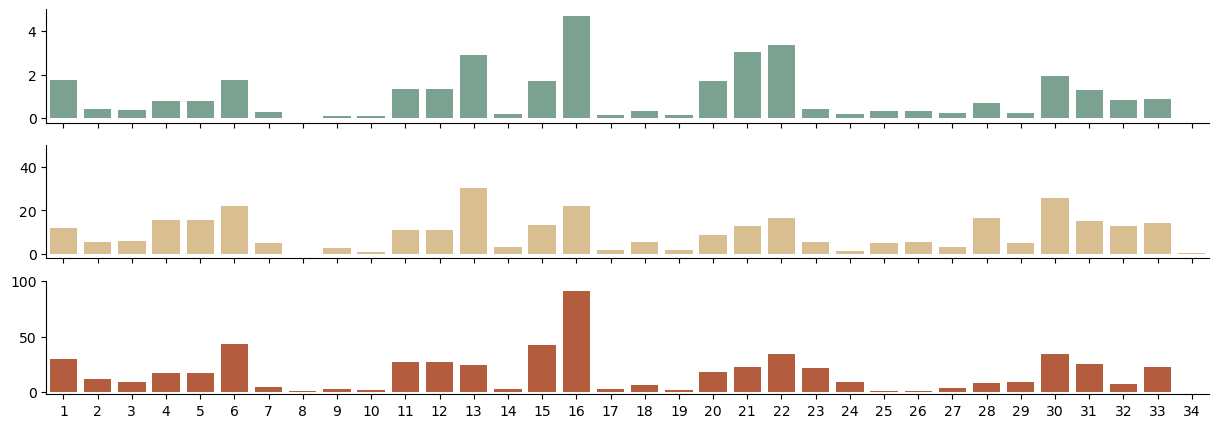

In [52]:
## 5. visualize size, snp no. and gene no. for each LD block
df_plot = df_ld_block[['QTL_no', 'block_size']].drop_duplicates()
df_plot['block_size'] = df_plot['block_size']/1e6
f, ax= plt.subplots(3,1, figsize=(15,5), sharex=True)
sns.barplot(df_plot, x='QTL_no', y= 'block_size', color='#74a892', ax=ax[0])
ax[0].set_ylim(-0.2,5)
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].spines[['right', 'top']].set_visible(False)

df_plot = df_ld_block[['QTL_no', 'No. of_mapped_SNP']].drop_duplicates()
df_plot['No. of_mapped_SNP'] = df_plot['No. of_mapped_SNP']/1e3
sns.barplot(df_plot, x='QTL_no', y= 'No. of_mapped_SNP', color='#e5c185', ax=ax[1])
ax[1].set_ylim(-2,50)
ax[1].set_ylabel('')
ax[1].set_xlabel('')
ax[1].spines[['right', 'top']].set_visible(False)

df_plot = df_ld_block[['QTL_no', 'gene_no']].drop_duplicates()
sns.barplot(df_plot, x='QTL_no', y= 'gene_no', color='#c7522a', ax=ax[2])
ax[2].set_ylim(-2,100)
ax[2].set_ylabel('')
ax[2].set_xlabel('')
ax[2].spines[['right', 'top']].set_visible(False)
plt.show()

In [519]:
## 6. save the LD block
import pickle
with open('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Gwas/data/LD_block/20250525/ld_block_info_20250903.pkl', 'wb') as outp:
    pickle.dump(df_ld_block, outp, pickle.HIGHEST_PROTOCOL)

In [73]:
##make a table of peak snp for each LD block

## 1. read input data
df_ld_block = pd.read_pickle('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Gwas/data/LD_block/20250525/ld_block_info_20250903.pkl')

## 2. get info of the peak snp for each LD block
peak_snp_info_list = {}
#df_temp = df_ld_block.reset_index().drop_duplicates(subset = 'Peak_SNP').set_index('Peak_SNP')
for qtl in df_ld_block['QTL_id']:
    peak_snp_info = df_ld_block.loc[df_ld_block['QTL_id']==qtl]['SNPs_nearby'].iloc[0].loc[qtl.split('|')[0]]
    peak_snp_info_list.update({qtl:peak_snp_info})
df_peak_snp_info = pd.DataFrame(peak_snp_info_list).transpose()

## 3. compute allele frequency for each peak snp
def reformat_allele(a1,a2,freq):
    freq = str(round(freq,2))+'%'
    return a1+'/'+a2+' ('+str(freq)+')'
df_peak_snp_info['alleles'] = df_peak_snp_info.apply(lambda x: reformat_allele(x['A1'], x['A2'],x['Freq']),axis=1)
df_peak_snp_info['chr']=df_peak_snp_info['chr'].astype(int)
df_peak_snp_info.sort_values(['chr', 'pos'])

,pos,chr,r2,-log10_P,A1,A2,Freq,b,se,p,alleles
1:13180420|T4_TDEN,13180420,1,1.0,7.324105,A,G,0.239254,0.12118,0.022191,0.0,A/G (0.24%)
1:53479201|T1_ADED,53479201,1,1.0,8.864031,T,C,0.112306,-0.204688,0.033781,0.0,T/C (0.11%)
2:8948407|T2_LFDE,8948407,2,1.0,7.276634,T,C,0.036708,-0.289373,0.053181,0.0,T/C (0.04%)
2:34062563|T1_TD,34062563,2,1.0,9.403263,C,A,0.221969,0.16054,0.025662,0.0,C/A (0.22%)
2:34072988|T1_Velocity,34072988,2,1.0,9.095406,C,A,0.220288,0.157306,0.025602,0.0,C/A (0.22%)
2:44880680|LDCI,44880680,2,1.0,6.893721,G,A,0.198669,0.150897,0.028568,0.0,G/A (0.2%)
2:48476767|TDDZ,48476767,2,1.0,8.054529,A,G,0.068563,-0.235815,0.040997,0.0,A/G (0.07%)
3:40121382|T4_ADED,40121382,3,1.0,7.50785,G,C,0.346084,0.129355,0.023369,0.0,G/C (0.35%)
3:52846402|T2_ADED,52846402,3,1.0,7.060117,C,T,0.060681,-0.227331,0.042477,0.0,C/T (0.06%)
5:3117060|LDCI,3117060,5,1.0,7.22189,A,G,0.255197,0.133457,0.024629,0.0,A/G (0.26%)


In [163]:
##make a table of gene information for each QTL
df_ortho_genes = pd.read_excel('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Database/ZebrafishGenomeAnnotation/ortho_genes_20250227.xlsx', sheet_name = 'human_orthos')
df_genes_in_block_list = []
for i in range(df_ld_block.shape[0]):
    #snp = df_ld_block.index[i]
    snp= df_ld_block['Peak_SNP'].iloc[0]
    trait = df_ld_block.iloc[i]['trait']
    qtl_id = df_ld_block.iloc[i]['QTL_id']
    small_block_genes = df_ld_block.iloc[i]['genes_in_small_block'][8].apply(lambda x: x.split(";Name=")[-1]).unique()
    big_block_genes = df_ld_block.iloc[i]['genes_in_big_block'][8].apply(lambda x: x.split(";Name=")[-1]).unique()

    ## if genes insdie the small block is less than 5, using the big block if it has more genes
    ## otherwise, still using the small block
    if len(small_block_genes) < 5 and len(big_block_genes) >len(small_block_genes):
        genes = big_block_genes
        r2 = 0.5
    else:
        genes = small_block_genes
        r2=0.6
    df_genes_in_block_list.append(pd.concat((pd.Series([qtl_id]*len(genes)),
                                             pd.Series([snp]*len(genes)), 
                                             pd.Series(genes), 
                                             pd.Series([trait]*len(genes)), 
                                             pd.Series([r2]*len(genes))),axis=1)) 

df_genes_in_block = pd.concat(df_genes_in_block_list)   
df_genes_in_block.columns = ['QTL_id','Peak_SNP', 'Mapped_genes', 'Trait', 'r2']
df_genes_in_block = pd.merge(df_genes_in_block, df_ortho_genes, how='left', left_on = 'Mapped_genes', right_on = 'zebrafish_symbol')
df_genes_in_block = df_genes_in_block.drop_duplicates(['Mapped_genes','Peak_SNP', 'Trait'])
df_genes_in_block = pd.merge(df_genes_in_block, df_ld_block[['chr', 'pos', 'QTL_id', 'QTL_no','block_start','block_end','block_size']], on='QTL_id')

##add gene coordinates
gene_corr=[]

for i in range(df_genes_in_block.shape[0]):
    if df_ld_block.loc[df_ld_block.QTL_id==df_genes_in_block.iloc[i,0],'r2'].iloc[0]==0.5:
        df_gtf_temp = df_ld_block.loc[df_ld_block.QTL_id==df_genes_in_block.iloc[i,0],].iloc[0]['genes_in_big_block']
    else:
        df_gtf_temp = df_ld_block.loc[df_ld_block.QTL_id==df_genes_in_block.iloc[i,0],].iloc[0]['genes_in_small_block']
    gene_temp = df_genes_in_block.iloc[i, 2]
    #df_genes_in_block.iloc[i][['gene_start', 'gene_end','gene_strand']]=df_gtf_temp.loc[df_gtf_temp[8].str.contains(gene_temp)][[3,4,6]]
    gene_corr_temp = df_gtf_temp.loc[df_gtf_temp[8].str.split(";Name=").str[-1]==gene_temp][[3,4,6]]
    if gene_corr_temp.shape[0]>1:
        print(i)
        break
    gene_corr.append(gene_corr_temp)
df_genes_in_block = pd.concat([df_genes_in_block, pd.concat(gene_corr,ignore_index=True)],axis=1)
df_genes_in_block['gene_start'] =df_genes_in_block[[3,4,6]].apply(lambda x: x[3] if x[6]=='+' else x[4], axis=1)
df_genes_in_block['gene_end'] =df_genes_in_block[[3,4,6]].apply(lambda x: x[4] if x[6]=='+' else x[3],axis=1)

#import pickle
#with open('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/zebrafish2human/processed_data/GWAS_candidate_genes_20260113.pkl', 'wb') as outp:
    #pickle.dump(df_genes_in_block, outp, pickle.HIGHEST_PROTOCOL)
df_genes_in_block



/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_38682/2517080567.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_genes_in_block = pd.concat(df_genes_in_block_list)


,QTL_id,Peak_SNP,Mapped_genes,Trait,r2,ZFIN ID,zebrafish_symbol,zebrafish_ens,ZFIN Name,human_symbol,...,pos,QTL_no,block_start,block_end,block_size,3,4,6,gene_start,gene_end
0,1:13180420|T4_TDEN,1:13180420,eif3bb,T4_TDEN,0.5,ZDB-GENE-090312-175,eif3bb,ENSDARG00000074213,"eukaryotic translation initiation factor 3, su...",EIF3B,...,13180420,1,11690229,13439814,1749585,11690360,11707665,+,11690360,11707665
1,1:13180420|T4_TDEN,1:13180420,si:dkey-26i13.8,T4_TDEN,0.5,NaN,NaN,NaN,NaN,NaN,...,13180420,1,11690229,13439814,1749585,11711226,11733130,+,11711226,11733130
2,1:13180420|T4_TDEN,1:13180420,chst12b.1,T4_TDEN,0.5,ZDB-GENE-090312-144,chst12b.1,ENSDARG00000077198,"carbohydrate sulfotransferase 12b, tandem dupl...",CHST12,...,13180420,1,11690229,13439814,1749585,11736420,11737595,+,11736420,11737595
3,1:13180420|T4_TDEN,1:13180420,ttyh3b,T4_TDEN,0.5,ZDB-GENE-051120-105,ttyh3b,ENSDARG00000007678,tweety family member 3b,TTYH3,...,13180420,1,11690229,13439814,1749585,11781544,11850353,-,11850353,11781544
4,1:13180420|T4_TDEN,1:13180420,iqce,T4_TDEN,0.5,ZDB-GENE-090312-217,iqce,ENSDARG00000089930,IQ motif containing E,IQCE,...,13180420,1,11690229,13439814,1749585,11854710,11878845,-,11878845,11854710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
636,23:4911792|T4_LFDE,1:13180420,slc6a1a,T4_LFDE,0.6,ZDB-GENE-060519-23,slc6a1a,ENSDARG00000045944,solute carrier family 6 member 1a,SLC6A1,...,4911792,33,4084863,4957204,872341,4834447,4855122,-,4855122,4834447
637,23:4911792|T4_LFDE,1:13180420,tnnc1a,T4_LFDE,0.6,ZDB-GENE-030523-1,tnnc1a,ENSDARG00000011400,troponin C type 1a (slow),TNNC1,...,4911792,33,4084863,4957204,872341,4890693,4895876,+,4890693,4895876
638,23:4911792|T4_LFDE,1:13180420,atp6ap1a,T4_LFDE,0.6,ZDB-GENE-090312-136,atp6ap1a,ENSDARG00000041417,ATPase H+ transporting accessory protein 1a,ATP6AP1,...,4911792,33,4084863,4957204,872341,4899238,4915118,-,4915118,4899238
639,23:4911792|T4_LFDE,1:13180420,tafazzin,T4_LFDE,0.6,ZDB-GENE-030131-684,tafazzin,ENSDARG00000041421,"tafazzin, phospholipid-lysophospholipid transa...",TAFAZZIN,...,4911792,33,4084863,4957204,872341,4915595,4925724,-,4925724,4915595


In [325]:
##prepare an output for table s2 for publication
df_tbs2 = df_genes_in_block[['Mapped_genes','zebrafish_ens', 'chr','gene_start','gene_end',6,'ZFIN Name','QTL_no', 'Trait', 'human_symbol', 'human_ens' ]]
df_tbs2.columns = ['zebrafish_gene_symbol', 'zebrafish_gene_ens','chr','gene_start','gene_end', 'strand', 'description','QTL_no','Trait', 'human_ortho_symbol', 'human_ortho_ens']

##add human gwas disease information 
wdir='/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/zebrafish2human/processed_data/'
df_gene_with_hgwas_disease = pd.read_pickle(wdir+'GWAS_candidate_human_ortho_efo_v1.pkl')
df_temp = df_gene_with_hgwas_disease[['Mapped_genes', 'Mapped_human_gwas_traits','Mapped_human_gwas_traits_efo']].copy()
df_temp['Mapped_human_gwas_traits'] = df_temp['Mapped_human_gwas_traits'].apply(lambda x: x if len(x)>0 else '')
df_temp['Mapped_human_gwas_traits_efo'] = df_temp['Mapped_human_gwas_traits_efo'].apply(lambda x: x if len(x)>0 else '')
df_temp = df_temp.drop_duplicates('Mapped_genes')
df_temp = pd.merge(df_tbs2, df_temp.drop_duplicates('Mapped_genes'), left_on='zebrafish_gene_symbol', right_on='Mapped_genes', how = 'left')

df_temp1 = df_temp.loc[df_temp.zebrafish_gene_ens.isna()].sort_values(['QTL_no', 'gene_start'])
df_temp2 = df_temp.loc[~df_temp.zebrafish_gene_ens.isna()].sort_values(['QTL_no', 'gene_start'])
df_temp = pd.concat([df_temp2, df_temp1])
output_dir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/submission_2025/Supplementary_tables/'
fn = 'Table S2 GWAS loci and candidate protein-coding genes.xlsx'
with pd.ExcelWriter(
        output_dir+fn,
        mode="a",
        engine="openpyxl",
        if_sheet_exists="replace",
    ) as writer:
    df_temp.to_excel(writer, sheet_name="candidate_genes", index=False)

#### LD block visualization

LD_block: chr05:66820226-67144845
plot region: chr05:66783124-67181946


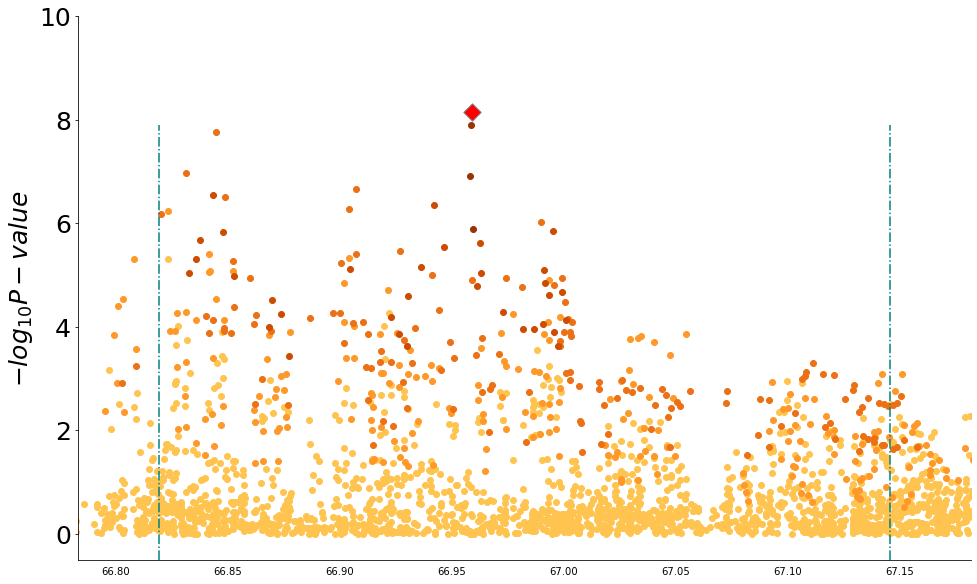

In [35]:
def Draw_LD_Block(df_ld_block_all, snp, order, output_path):
    
    
    chr_num=snp.split(":")[0]
    
    if int(chr_num)<10:
        chr_num='0'+chr_num
    else:
        chr_num=chr_num
    chr_num='chr'+chr_num 
    
    df_LDblock=df_ld_block_all.iloc[order,:]['SNPs_nearby']
    peak_logP=df_ld_block_all.iloc[order,:]['peak_snp_log10P']
    trait = df_ld_block_all.iloc[order,:]['trait']
    peak_pos=int(snp.split(":")[1])
    
    if df_ld_block_all.iloc[order,:]['genes_in_small_block'].shape[0]>5:
        left=df_ld_block_all.iloc[order,:]['small_block_start']
        right=df_ld_block_all.iloc[order,:]['small_block_end']
        
    else:
        left=df_ld_block_all.iloc[order,:]['big_block_start']
        right=df_ld_block_all.iloc[order,:]['big_block_end']
    
    interval = max(abs(peak_pos-left), abs(peak_pos-right))
    
    df_LDblock=df_LDblock.loc[(df_LDblock['pos']>(min(left, peak_pos)*0.9))&(df_LDblock['pos']<(max(right, peak_pos)*1.1))]
    
    df_plot=df_ld_block_all.iloc[order,:]['SNPs_nearby']
    
    df_plot_g2=df_plot.loc[(df_plot['r2']>0.6)&(df_plot['r2']<0.8)]
    df_plot_g3=df_plot.loc[(df_plot['r2']>0.4)&(df_plot['r2']<0.6)]
    df_plot_g4=df_plot.loc[(df_plot['r2']>0.2)&(df_plot['r2']<0.4)]
    df_plot_g5=df_plot.loc[(df_plot['r2']<0.2)]
    df_plot_g1=df_plot.loc[df_plot['r2']>0.8]
    f = plt.figure(figsize=(16,10))
    color_platte = ['#fec44f','#fe9929','#ec7014','#cc4c02','#993404','#ff0000']
    #color_platte = ['#fdd49e','#fdbb84','#fc8d59','#ef6548','#d7301f','#ff0000']
    plt.scatter(df_plot_g5['pos']/1000000, df_plot_g5['-log10_P'], c=color_platte[0], label='r2<0.2')
    plt.scatter(df_plot_g4['pos']/1000000, df_plot_g4['-log10_P'], c=color_platte[1], label='0.2<r2<0.4')
    plt.scatter(df_plot_g3['pos']/1000000, df_plot_g3['-log10_P'], c=color_platte[2], label='0.4<r2<0.6')
    plt.scatter(df_plot_g2['pos']/1000000, df_plot_g2['-log10_P'], c=color_platte[3], label='0.6<r2<0.8')
    plt.scatter(df_plot_g1['pos']/1000000, df_plot_g1['-log10_P'], c=color_platte[4], label='0.8<r2<1')
    plt.scatter(x=peak_pos/1000000, y=peak_logP, c=color_platte[5], label='r2=1', s=150, marker='D', edgecolor='grey')
    ax=plt.gca()
    plt.ylim(-0.5,10)
    plt.xlim((min(left, peak_pos)-interval*0.2)/1000000, (max(right, peak_pos)+interval*0.2)/1000000)
    #plt.xlim((peak_pos-interval-10000)/1000000, (peak_pos+interval+10000)/1000000)
    plt.ylabel(r'$-log_{10}P-value$', fontsize=25)
    plt.tick_params(
                    axis='both',          # changes apply to the x-axis
                    which='both',      # both major and minor ticks are affected
                    bottom=False,      # ticks along the bottom edge are on
                    top=False,         # ticks along the top edge are off
                    labelbottom=True)
    plt.yticks(size=25)
    plt.axvline(x = (min(left, peak_pos)-1000)/1000000, c='#007f7f', linestyle = '-.', ymax = 0.8)
    plt.axvline(x = (max(right, peak_pos)+1000)/1000000, c='#007f7f', linestyle = '-.', ymax = 0.8)
    print('LD_block: %s:%i-%i'%(chr_num, (min(left, peak_pos)), max(right, peak_pos)))
    print('plot region: %s:%i-%i'%(chr_num, min(left, peak_pos)-interval*0.2, max(right, peak_pos)+interval*0.2))
    #plt.title(trait,size=40)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.savefig(output_path+trait+'_LD_'+chr_num+'_'+str(peak_pos)+'_snp.tif',bbox_inches='tight')
    plt.show()
    #return f
Draw_LD_Block(df_ld_block, '5:66959339', 7,output_path)